<a href="https://colab.research.google.com/github/hadri1-bisch/real-data-proect/blob/main/Final_real_data_hotel_nuit_e_hesta_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

df HESTA provenances avec les principales villes suisse a analyser


In [9]:
#from google.colab import drive
#drive.mount('/content/drive')

# **EDA**
**Top marché les 3-4 dernières années ?** (évolution) on peut aussi mettre le top marché de 2013 voir s’il y a des gros changements ?? (stacked bar chart)

**Taux d’occupation par mois les 3-4 dernières années**, pour savoir quels sont les mois pour lesquels il faut augmenter la demande  (line chart avec une ligne par année)

**Nuitées moyennes** par mois

Quels sont les marchés qui viennent déjà pendant la saison creuse

**Taux d’occupation dans les villes concurrentes suisse ou/et europe** (Lines chart) si une/des villes ont une meilleure répartition : Voir quels sont les marchés elles arrivent à attirer en basse saison

Data **aéroport **: un marché est intéressant que s’il y a des vols directs à destination de geneve pendant la basse saison


In [10]:
!pip install pxweb

In [11]:
import requests as r
import pandas as pd


AJOUTER 2025??????

In [12]:
years = [ "2013", "2014"
"2015","2016","2017","2018","2019",
"2022","2023","2024","2025"
]

In [13]:
communes = {
"261": "Zürich",
"3856": "Interlaken",
"3866": "Matten bei Interlaken",
"1061": "Luzern",
"2701": "Basel",
"3203": "St Gallen",
"3786": "St Moritz",
"3851": "Davos",
"5113": "Locarno",
"5586": "Lausanne",
"5661": "Château-d'Oex",
"5886": "Montreux",
"6024": "Nendaz",
"6288": "Saas-Fee",
"6290": "Zermatt",
"6621": "Genève",
"351": "Bern"
}

pour gérer le crash out

In [14]:
import requests
import pandas as pd
from io import StringIO
import time

url = "https://www.pxweb.bfs.admin.ch/api/v1/fr/px-x-1003020000_101/px-x-1003020000_101.px"

dfs = []

for code, name in communes.items():

    print("Téléchargement :", name)

    data = {
      "query": [

        {
          "code": "Jahr",
          "selection": {
            "filter": "item",
            "values": years
          }
        },

        {
          "code": "Monat",
          "selection": {
            "filter": "all",
            "values": ["*"]
          }
        },

        {
          "code": "Gemeinde",
          "selection": {
            "filter": "item",
            "values": [code]
          }
        },

        {
          "code": "Herkunftsland",
          "selection": {
            "filter": "all",
            "values": ["*"]
          }
        }

      ],

      "response": {
        "format": "csv"
      }

    }

    success = False
    attempts = 0

    while not success and attempts < 5:

        try:

            r = requests.post(url, json=data, timeout=120)

            df = pd.read_csv(StringIO(r.text))

            df["Commune_nom"] = name

            dfs.append(df)

            success = True

            # sauvegarde intermédiaire
            df_temp = pd.concat(dfs, ignore_index=True)
            df_temp.to_csv("tourisme_backup.csv", index=False)

            print("✔ Sauvegarde effectuée")

        except Exception as e:

            attempts += 1
            print("Erreur → retry", attempts)
            time.sleep(5)

    if not success:
        print("⚠️ Impossible de télécharger :", name)

df = pd.concat(dfs, ignore_index=True)

# sauvegarde finale
df.to_csv("tourisme_final.csv", index=False)

print("Téléchargement terminé")
print(df.shape)

Téléchargement : Zürich
✔ Sauvegarde effectuée
Téléchargement : Interlaken
✔ Sauvegarde effectuée
Téléchargement : Matten bei Interlaken
✔ Sauvegarde effectuée
Téléchargement : Luzern
✔ Sauvegarde effectuée
Téléchargement : Basel
✔ Sauvegarde effectuée
Téléchargement : St Gallen
✔ Sauvegarde effectuée
Téléchargement : St Moritz
✔ Sauvegarde effectuée
Téléchargement : Davos
✔ Sauvegarde effectuée
Téléchargement : Locarno
✔ Sauvegarde effectuée
Téléchargement : Lausanne
✔ Sauvegarde effectuée
Téléchargement : Château-d'Oex
✔ Sauvegarde effectuée
Téléchargement : Montreux
✔ Sauvegarde effectuée
Téléchargement : Nendaz
✔ Sauvegarde effectuée
Téléchargement : Saas-Fee
✔ Sauvegarde effectuée
Téléchargement : Zermatt
✔ Sauvegarde effectuée
Téléchargement : Genève
✔ Sauvegarde effectuée
Téléchargement : Bern
✔ Sauvegarde effectuée
Téléchargement terminé
(0, 2)


In [15]:
import requests
import pandas as pd
from io import StringIO
import time

url = "https://www.pxweb.bfs.admin.ch/api/v1/fr/px-x-1003020000_101/px-x-1003020000_101.px"

years = [ "2013", "2014","2015","2016","2017","2018","2019","2022","2023","2024","2025"]

communes = {
    "261": "Zürich", "3856": "Interlaken", "3866": "Matten bei Interlaken",
    "1061": "Luzern", "2701": "Basel", "3203": "St Gallen",
    "3786": "St Moritz", "3851": "Davos", "5113": "Locarno",
    "5586": "Lausanne", "5661": "Château-d'Oex", "5886": "Montreux",
    "6024": "Nendaz", "6288": "Saas-Fee", "6290": "Zermatt", "6621": "Genève","351": "Bern"
}

dfs = []

for code, name in communes.items():
    print("Téléchargement :", name)
    data = {
      "query": [
        {"code": "Jahr", "selection": {"filter": "item", "values": years}},
        {"code": "Monat", "selection": {"filter": "all", "values": ["*"]}},
        {"code": "Gemeinde", "selection": {"filter": "item", "values": [code]}},
        {"code": "Herkunftsland", "selection": {"filter": "all", "values": ["*"]}}
      ],
      "response": {"format": "csv"}
    }

    success = False
    attempts = 0
    while not success and attempts < 5:
        try:
            r = requests.post(url, json=data, timeout=120)
            df_temp = pd.read_csv(StringIO(r.text))
            df_temp["Commune_nom"] = name
            dfs.append(df_temp)
            success = True
            print("✔", name)
        except Exception as e:
            attempts += 1
            print("Erreur → retry", attempts, e)
            time.sleep(5)

    if not success:
        print("⚠️ Impossible :", name)
    time.sleep(1)  # éviter de spammer l'API

df = pd.concat(dfs, ignore_index=True)
df.to_csv("tourisme_final.csv", index=False)
print("\n✅ Téléchargement terminé")
print(df.shape)
df.head()

Téléchargement : Zürich
✔ Zürich
Téléchargement : Interlaken
✔ Interlaken
Téléchargement : Matten bei Interlaken
✔ Matten bei Interlaken
Téléchargement : Luzern
✔ Luzern
Téléchargement : Basel
✔ Basel
Téléchargement : St Gallen
✔ St Gallen
Téléchargement : St Moritz
✔ St Moritz
Téléchargement : Davos
✔ Davos
Téléchargement : Locarno
✔ Locarno
Téléchargement : Lausanne
✔ Lausanne
Téléchargement : Château-d'Oex
✔ Château-d'Oex
Téléchargement : Montreux
✔ Montreux
Téléchargement : Nendaz
✔ Nendaz
Téléchargement : Saas-Fee
✔ Saas-Fee
Téléchargement : Zermatt
✔ Zermatt
Téléchargement : Genève
✔ Genève
Téléchargement : Bern
✔ Bern

✅ Téléchargement terminé
(1859, 151)


,Année,Mois,Commune,Pays de provenance - total Arrivées,Pays de provenance - total Nuitées,Suisse Arrivées,Suisse Nuitées,Allemagne Arrivées,Allemagne Nuitées,France Arrivées,...,Slovénie Arrivées,Slovénie Nuitées,Tchéquie Arrivées,Tchéquie Nuitées,Ukraine Arrivées,Ukraine Nuitées,Serbie Arrivées,Serbie Nuitées,Commune_nom,Bad Request
0,2013.0,Total de l'année,Zürich,1579867.0,2830003.0,369334.0,586288.0,225766,388580,45660.0,...,1361,2535,4975,10885,5748,13660,3022,5349,Zürich,NaN
1,2013.0,Janvier,Zürich,100632.0,181631.0,25728.0,40846.0,15677,27533,3273.0,...,99,196,310,672,564,1310,239,438,Zürich,NaN
2,2013.0,Février,Zürich,97826.0,174816.0,25084.0,40376.0,15938,27551,3190.0,...,92,179,294,697,434,1055,182,357,Zürich,NaN
3,2013.0,Mars,Zürich,120931.0,211512.0,30317.0,48438.0,19286,32658,3709.0,...,111,184,478,891,570,1298,284,515,Zürich,NaN
4,2013.0,Avril,Zürich,122964.0,221251.0,27452.0,44723.0,19004,31404,3599.0,...,107,210,380,658,429,1151,409,686,Zürich,NaN


In [16]:

print(df.head())
print(df.shape)


    Année              Mois Commune  Pays de provenance - total Arrivées  \
0  2013.0  Total de l'année  Zürich                            1579867.0   
1  2013.0           Janvier  Zürich                             100632.0   
2  2013.0           Février  Zürich                              97826.0   
3  2013.0              Mars  Zürich                             120931.0   
4  2013.0             Avril  Zürich                             122964.0   

   Pays de provenance - total Nuitées  Suisse Arrivées  Suisse Nuitées  \
0                           2830003.0         369334.0        586288.0   
1                            181631.0          25728.0         40846.0   
2                            174816.0          25084.0         40376.0   
3                            211512.0          30317.0         48438.0   
4                            221251.0          27452.0         44723.0   

  Allemagne Arrivées Allemagne Nuitées  France Arrivées  ...  \
0             225766            38

In [17]:
df.columns

Index(['Année', 'Mois', 'Commune', 'Pays de provenance - total Arrivées',
       'Pays de provenance - total Nuitées', 'Suisse Arrivées',
       'Suisse Nuitées', 'Allemagne Arrivées', 'Allemagne Nuitées',
       'France Arrivées',
       ...
       'Slovénie Arrivées', 'Slovénie Nuitées', 'Tchéquie Arrivées',
       'Tchéquie Nuitées', 'Ukraine Arrivées', 'Ukraine Nuitées',
       'Serbie Arrivées', 'Serbie Nuitées', 'Commune_nom', 'Bad Request'],
      dtype='object', length=151)

In [18]:
df = df.drop(columns=["Bad Request"], errors="ignore")

In [19]:
df.head(14)

,Année,Mois,Commune,Pays de provenance - total Arrivées,Pays de provenance - total Nuitées,Suisse Arrivées,Suisse Nuitées,Allemagne Arrivées,Allemagne Nuitées,France Arrivées,...,Slovaquie Nuitées,Slovénie Arrivées,Slovénie Nuitées,Tchéquie Arrivées,Tchéquie Nuitées,Ukraine Arrivées,Ukraine Nuitées,Serbie Arrivées,Serbie Nuitées,Commune_nom
0,2013.0,Total de l'année,Zürich,1579867.0,2830003.0,369334.0,586288.0,225766,388580,45660.0,...,4786,1361,2535,4975,10885,5748,13660,3022,5349,Zürich
1,2013.0,Janvier,Zürich,100632.0,181631.0,25728.0,40846.0,15677,27533,3273.0,...,307,99,196,310,672,564,1310,239,438,Zürich
2,2013.0,Février,Zürich,97826.0,174816.0,25084.0,40376.0,15938,27551,3190.0,...,370,92,179,294,697,434,1055,182,357,Zürich
3,2013.0,Mars,Zürich,120931.0,211512.0,30317.0,48438.0,19286,32658,3709.0,...,419,111,184,478,891,570,1298,284,515,Zürich
4,2013.0,Avril,Zürich,122964.0,221251.0,27452.0,44723.0,19004,31404,3599.0,...,322,107,210,380,658,429,1151,409,686,Zürich
5,2013.0,Mai,Zürich,143393.0,254651.0,31341.0,47605.0,22534,38906,4014.0,...,312,72,139,366,710,527,1338,299,479,Zürich
6,2013.0,Juin,Zürich,153866.0,277179.0,32025.0,51226.0,19679,33962,3904.0,...,439,139,243,343,764,404,1030,299,474,Zürich
7,2013.0,Juillet,Zürich,156726.0,283204.0,29660.0,49749.0,19755,34611,4198.0,...,431,111,190,429,819,489,1144,166,271,Zürich
8,2013.0,Août,Zürich,156648.0,290555.0,31754.0,51667.0,19963,35098,3970.0,...,343,94,154,496,970,505,1124,164,285,Zürich
9,2013.0,Septembre,Zürich,147049.0,262895.0,34224.0,54609.0,19927,34135,3672.0,...,498,143,277,425,890,401,890,281,509,Zürich


In [20]:
df.columns

Index(['Année', 'Mois', 'Commune', 'Pays de provenance - total Arrivées',
       'Pays de provenance - total Nuitées', 'Suisse Arrivées',
       'Suisse Nuitées', 'Allemagne Arrivées', 'Allemagne Nuitées',
       'France Arrivées',
       ...
       'Slovaquie Nuitées', 'Slovénie Arrivées', 'Slovénie Nuitées',
       'Tchéquie Arrivées', 'Tchéquie Nuitées', 'Ukraine Arrivées',
       'Ukraine Nuitées', 'Serbie Arrivées', 'Serbie Nuitées', 'Commune_nom'],
      dtype='object', length=150)

à transformer en tidy dataset (df_tidy)


In [21]:
import pandas as pd
df = pd.read_csv("tourisme_final.csv")
print(df.shape)
print(df.columns.tolist()[:8])
df.head()

(1859, 151)
['Année', 'Mois', 'Commune', 'Pays de provenance - total Arrivées', 'Pays de provenance - total Nuitées', 'Suisse Arrivées', 'Suisse Nuitées', 'Allemagne Arrivées']


,Année,Mois,Commune,Pays de provenance - total Arrivées,Pays de provenance - total Nuitées,Suisse Arrivées,Suisse Nuitées,Allemagne Arrivées,Allemagne Nuitées,France Arrivées,...,Slovénie Arrivées,Slovénie Nuitées,Tchéquie Arrivées,Tchéquie Nuitées,Ukraine Arrivées,Ukraine Nuitées,Serbie Arrivées,Serbie Nuitées,Commune_nom,Bad Request
0,2013.0,Total de l'année,Zürich,1579867.0,2830003.0,369334.0,586288.0,225766,388580,45660.0,...,1361,2535,4975,10885,5748,13660,3022,5349,Zürich,NaN
1,2013.0,Janvier,Zürich,100632.0,181631.0,25728.0,40846.0,15677,27533,3273.0,...,99,196,310,672,564,1310,239,438,Zürich,NaN
2,2013.0,Février,Zürich,97826.0,174816.0,25084.0,40376.0,15938,27551,3190.0,...,92,179,294,697,434,1055,182,357,Zürich,NaN
3,2013.0,Mars,Zürich,120931.0,211512.0,30317.0,48438.0,19286,32658,3709.0,...,111,184,478,891,570,1298,284,515,Zürich,NaN
4,2013.0,Avril,Zürich,122964.0,221251.0,27452.0,44723.0,19004,31404,3599.0,...,107,210,380,658,429,1151,409,686,Zürich,NaN


In [22]:
# copie du dataset original
df_tidy = df.copy()

# colonnes d'identification
id_vars = ["Année", "Mois", "Commune", "Commune_nom"]

# toutes les autres colonnes
value_vars = [col for col in df_tidy.columns if col not in id_vars]

# passer du format large au format long
df_long = df_tidy.melt(
    id_vars=id_vars,
    value_vars=value_vars,
    var_name="variable",
    value_name="valeur"
)

# séparer pays et type (Arrivées / Nuitées)
df_long[["Pays", "Type"]] = df_long["variable"].str.rsplit(" ", n=1, expand=True)

# supprimer la colonne intermédiaire
df_long = df_long.drop(columns="variable")

# remettre Arrivées et Nuitées en colonnes
df_tidy = df_long.pivot_table(
    index=["Année", "Mois", "Commune", "Commune_nom", "Pays"],
    columns="Type",
    values="valeur",
    aggfunc="sum"
).reset_index()

# enlever le nom de colonne généré par pivot
df_tidy.columns.name = None

df_tidy["Arrivées"] = (
    df_tidy["Arrivées"]
    .astype(str)
    .str.replace(" ", "")
    .str.replace(",", "")
)

df_tidy["Arrivées"] = pd.to_numeric(df_tidy["Arrivées"], errors="coerce")

# voir le résultat
df_tidy.head()

,Année,Mois,Commune,Commune_nom,Pays,Arrivées,Nuitées,Request
0,2013.0,Août,Basel,Basel,Afrique du Sud,68.0,161,NaN
1,2013.0,Août,Basel,Basel,Allemagne,10025.0,16109,NaN
2,2013.0,Août,Basel,Basel,Arabie saoudite,129.0,380,NaN
3,2013.0,Août,Basel,Basel,Argentine,35.0,80,NaN
4,2013.0,Août,Basel,Basel,Australie,497.0,1110,NaN


In [23]:
df_tidy.columns

Index(['Année', 'Mois', 'Commune', 'Commune_nom', 'Pays', 'Arrivées',
       'Nuitées', 'Request'],
      dtype='object')

In [24]:
df_tidy["Commune_nom"].unique()

array(['Basel', 'Bern', 'Davos', 'Genève', 'Lausanne', 'Locarno',
       'Luzern', 'Montreux', 'Nendaz', 'Zermatt', 'St Moritz',
       'St Gallen', 'Zürich'], dtype=object)

In [25]:
print(df.shape)
print(df_tidy.shape)

(1859, 151)
(137566, 8)


segmenter les clients par nationnalité, idée: trouves les potentiels interessé à l'aide de moyenne annuel par nationnalité par année pour lausanne


In [26]:
df_tidy.columns

Index(['Année', 'Mois', 'Commune', 'Commune_nom', 'Pays', 'Arrivées',
       'Nuitées', 'Request'],
      dtype='object')

In [27]:
# sélectionner Lausanne
lausanne_df = df_tidy[df_tidy["Commune_nom"] == "Lausanne"]

# nombre de clients par nationalité et par année
clients_par_marche = (
    lausanne_df
    .groupby(["Année", "Pays"])["Arrivées"]
    .sum()
    .reset_index()
)

# afficher le résultat
clients_par_marche.sort_values(["Année", "Arrivées"], ascending=[True, False])

,Année,Pays,Arrivées
51,2013.0,Pays de provenance - total,727354.0
64,2013.0,Suisse,332232.0
29,2013.0,France,89292.0
38,2013.0,Italie,32750.0
58,2013.0,Royaume-Uni,32016.0
...,...,...,...
758,2025.0,Bélarus,246.0
790,2025.0,Oman,242.0
776,2025.0,Islande,210.0
754,2025.0,Bahreïn,198.0


In [28]:
#plus gros marché pour lausanne:
lausanne_df.head()


,Année,Mois,Commune,Commune_nom,Pays,Arrivées,Nuitées,Request
296,2013.0,Août,Lausanne,Lausanne,Afrique du Sud,48.0,176,NaN
297,2013.0,Août,Lausanne,Lausanne,Allemagne,1662.0,3125,NaN
298,2013.0,Août,Lausanne,Lausanne,Arabie saoudite,464.0,1629,NaN
299,2013.0,Août,Lausanne,Lausanne,Argentine,32.0,147,NaN
300,2013.0,Août,Lausanne,Lausanne,Australie,194.0,460,NaN


In [29]:

### Total depuis 2013 ????
top_marche = (
    lausanne_df
    .groupby("Pays")["Arrivées"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_marche.head(11)

,Pays,Arrivées
0,Pays de provenance - total,9742058.0
1,Suisse,4662958.0
2,France,1223224.0
3,États-Unis,492700.0
4,Allemagne,399434.0
5,Royaume-Uni,394624.0
6,Italie,332188.0
7,Chine,239464.0
8,Espagne,157516.0
9,Belgique,128004.0


In [30]:
lausanne_total = df_tidy[df_tidy["Commune_nom"] == "Lausanne"]["Arrivées"].sum()

print("Total arrivées Lausanne :", lausanne_total)

Total arrivées Lausanne : 19484116.0


garder les marché interesasnt pour lausanne:

In [31]:
top_markets = [
    "Suisse",
    "France",
    "États-Unis",
    "Allemagne",
    "Royaume-Uni",
    "Italie",
    "Chine",
    "Espagne",
    "Belgique",
    "Pays-Bas"
]
lausanne_df = df_tidy[df_tidy["Commune_nom"] == "Lausanne"]
lausanne_top = lausanne_df[lausanne_df["Pays"].isin(top_markets)]
lausanne_top["Pays"].unique()

array(['Allemagne', 'Belgique', 'Chine', 'Espagne', 'France', 'Italie',
       'Pays-Bas', 'Royaume-Uni', 'Suisse', 'États-Unis'], dtype=object)

In [32]:
lausanne_top.groupby("Pays")["Arrivées"].sum().sort_values(ascending=False)

,Arrivées
Pays,
Suisse,4662958.0
France,1223224.0
États-Unis,492700.0
Allemagne,399434.0
Royaume-Uni,394624.0
Italie,332188.0
Chine,239464.0
Espagne,157516.0
Belgique,128004.0


heat map clients/années

In [33]:
lausanne_heat = lausanne_top.groupby(["Pays","Année"])["Arrivées"].sum().reset_index()
heatmap_data = lausanne_heat.pivot(
    index="Pays",
    columns="Année",
    values="Arrivées"
)

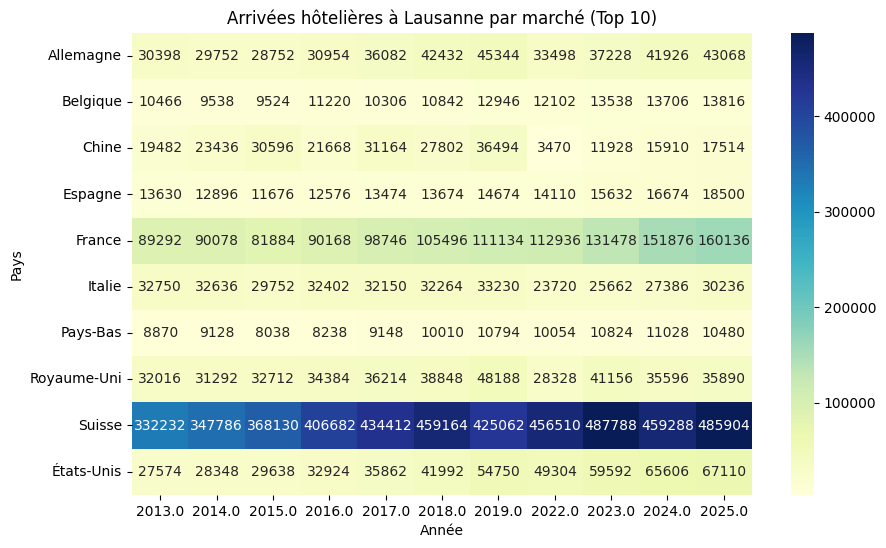

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Arrivées hôtelières à Lausanne par marché (Top 10)")
plt.ylabel("Pays")
plt.xlabel("Année")

plt.show()

moyenne de toutes les années

/tmp/ipykernel_2397/1489618480.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lausanne_month["Mois"] = pd.Categorical(
/tmp/ipykernel_2397/1489618480.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lausanne_heat = lausanne_month.groupby(["Pays","Mois"])["Arrivées"].mean().reset_index()


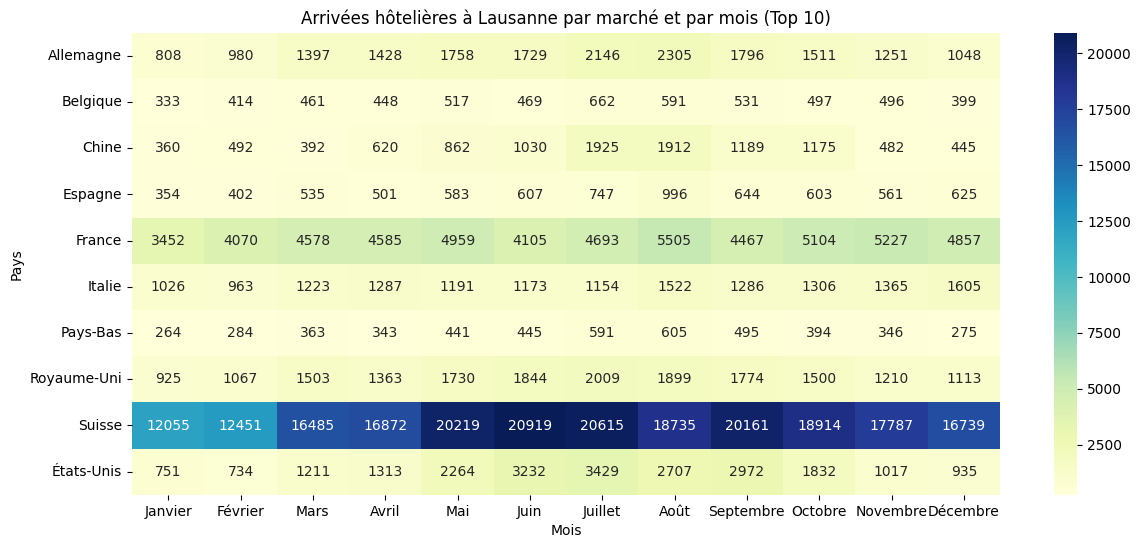

In [35]:
# 1️⃣ enlever les totaux annuels
lausanne_month = lausanne_top[lausanne_top["Mois"] != "Total de l'année"]

# 2️⃣ ordre correct des mois
month_order = [
    "Janvier","Février","Mars","Avril","Mai","Juin",
    "Juillet","Août","Septembre","Octobre","Novembre","Décembre"
]

lausanne_month["Mois"] = pd.Categorical(
    lausanne_month["Mois"],
    categories=month_order,
    ordered=True
)

# 3️⃣ moyenne des arrivées par mois et par pays
lausanne_heat = lausanne_month.groupby(["Pays","Mois"])["Arrivées"].mean().reset_index()

# 4️⃣ pivot table
heatmap_data = lausanne_heat.pivot(
    index="Pays",
    columns="Mois",
    values="Arrivées"
)

# 5️⃣ heatmap

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Arrivées hôtelières à Lausanne par marché et par mois (Top 10)")
plt.ylabel("Pays")
plt.xlabel("Mois")

plt.show()

graphes analyse clients par nationnalité 2022

/tmp/ipykernel_2397/4246778726.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lausanne_2022["Mois"] = pd.Categorical(
/tmp/ipykernel_2397/4246778726.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lausanne_heat_2022 = lausanne_2022.groupby(["Pays","Mois"])["Arrivées"].sum().reset_index()


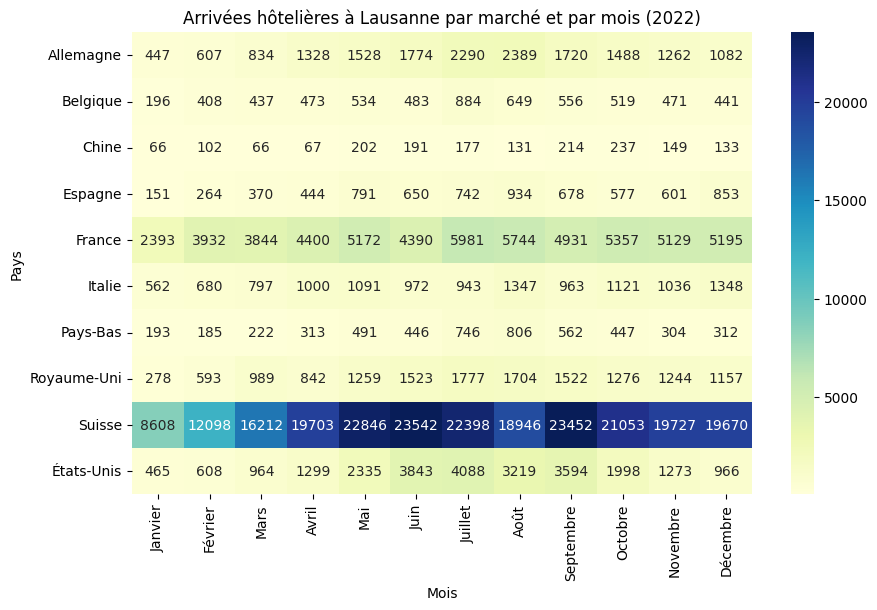

In [36]:
# Filtrer Lausanne
lausanne_df = df_tidy[df_tidy["Commune_nom"] == "Lausanne"]

# garder seulement les top 10 marchés
lausanne_top = lausanne_df[lausanne_df["Pays"].isin(top_markets)]

# filtrer uniquement l'année 2022
lausanne_2022 = lausanne_top[lausanne_top["Année"] == 2022]

# ordre des mois
mois_ordre = [
    "Janvier","Février","Mars","Avril","Mai","Juin",
    "Juillet","Août","Septembre","Octobre","Novembre","Décembre"
]

lausanne_2022["Mois"] = pd.Categorical(
    lausanne_2022["Mois"],
    categories=mois_ordre,
    ordered=True
)

# préparation heatmap
lausanne_heat_2022 = lausanne_2022.groupby(["Pays","Mois"])["Arrivées"].sum().reset_index()

heatmap_2022 = lausanne_heat_2022.pivot(
    index="Pays",
    columns="Mois",
    values="Arrivées"
)

# graphique
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_2022,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Arrivées hôtelières à Lausanne par marché et par mois (2022)")
plt.ylabel("Pays")
plt.xlabel("Mois")

plt.show()

graphes analyse clients par nationnalité 2023

/tmp/ipykernel_2397/700287444.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lausanne_2023["Mois"] = pd.Categorical(
/tmp/ipykernel_2397/700287444.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lausanne_heat_2023 = lausanne_2023.groupby(["Pays","Mois"])["Arrivées"].sum().reset_index()


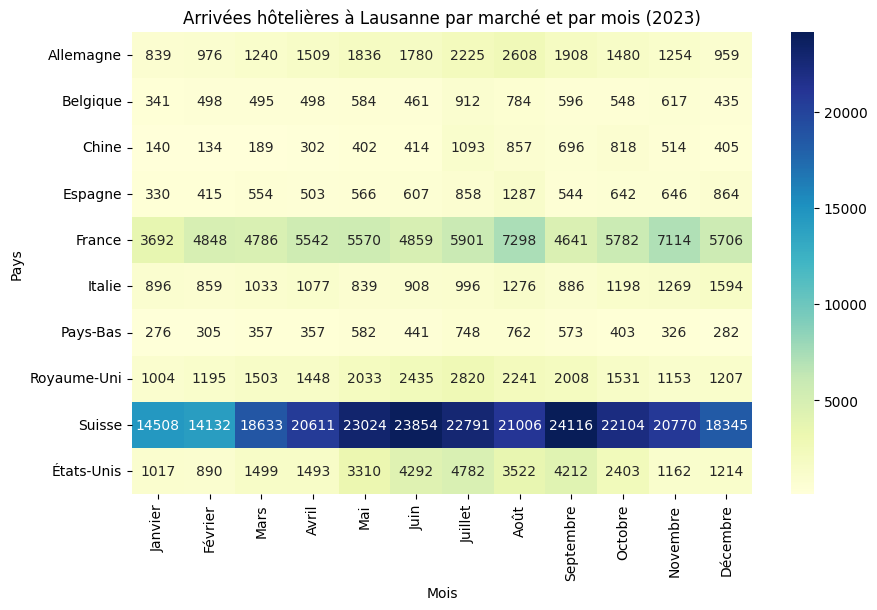

In [37]:
# Filtrer Lausanne
lausanne_df = df_tidy[df_tidy["Commune_nom"] == "Lausanne"]

# garder seulement les top 10 marchés
lausanne_top = lausanne_df[lausanne_df["Pays"].isin(top_markets)]

# filtrer uniquement l'année 2023
lausanne_2023 = lausanne_top[lausanne_top["Année"] == 2023]

# ordre des mois
mois_ordre = [
    "Janvier","Février","Mars","Avril","Mai","Juin",
    "Juillet","Août","Septembre","Octobre","Novembre","Décembre"
]

lausanne_2023["Mois"] = pd.Categorical(
    lausanne_2023["Mois"],
    categories=mois_ordre,
    ordered=True
)

# préparation heatmap
lausanne_heat_2023 = lausanne_2023.groupby(["Pays","Mois"])["Arrivées"].sum().reset_index()

heatmap_2023 = lausanne_heat_2023.pivot(
    index="Pays",
    columns="Mois",
    values="Arrivées"
)

# graphique
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_2023,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Arrivées hôtelières à Lausanne par marché et par mois (2023)")
plt.ylabel("Pays")
plt.xlabel("Mois")

plt.show()

graphes analyse clients par nationnalité 2024

/tmp/ipykernel_2397/1588796899.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lausanne_2024["Mois"] = pd.Categorical(
/tmp/ipykernel_2397/1588796899.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lausanne_heat_2024 = lausanne_2024.groupby(["Pays","Mois"])["Arrivées"].sum().reset_index()


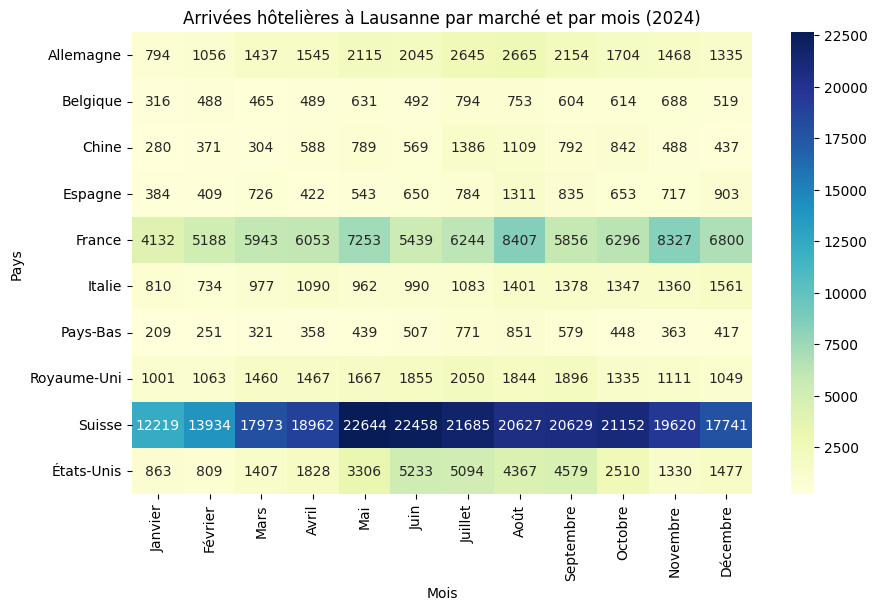

In [38]:
# Filtrer Lausanne
lausanne_df = df_tidy[df_tidy["Commune_nom"] == "Lausanne"]

# garder seulement les top 10 marchés
lausanne_top = lausanne_df[lausanne_df["Pays"].isin(top_markets)]

# filtrer uniquement l'année 2024
lausanne_2024 = lausanne_top[lausanne_top["Année"] == 2024]

# ordre des mois
mois_ordre = [
    "Janvier","Février","Mars","Avril","Mai","Juin",
    "Juillet","Août","Septembre","Octobre","Novembre","Décembre"
]

lausanne_2024["Mois"] = pd.Categorical(
    lausanne_2024["Mois"],
    categories=mois_ordre,
    ordered=True
)

# préparation heatmap
lausanne_heat_2024 = lausanne_2024.groupby(["Pays","Mois"])["Arrivées"].sum().reset_index()

heatmap_2024 = lausanne_heat_2024.pivot(
    index="Pays",
    columns="Mois",
    values="Arrivées"
)

# graphique

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_2024,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Arrivées hôtelières à Lausanne par marché et par mois (2024)")
plt.ylabel("Pays")
plt.xlabel("Mois")

plt.show()

evolution des fréquentation par nationnalité

/tmp/ipykernel_2397/1165474512.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lausanne_recent["Mois"] = pd.Categorical(


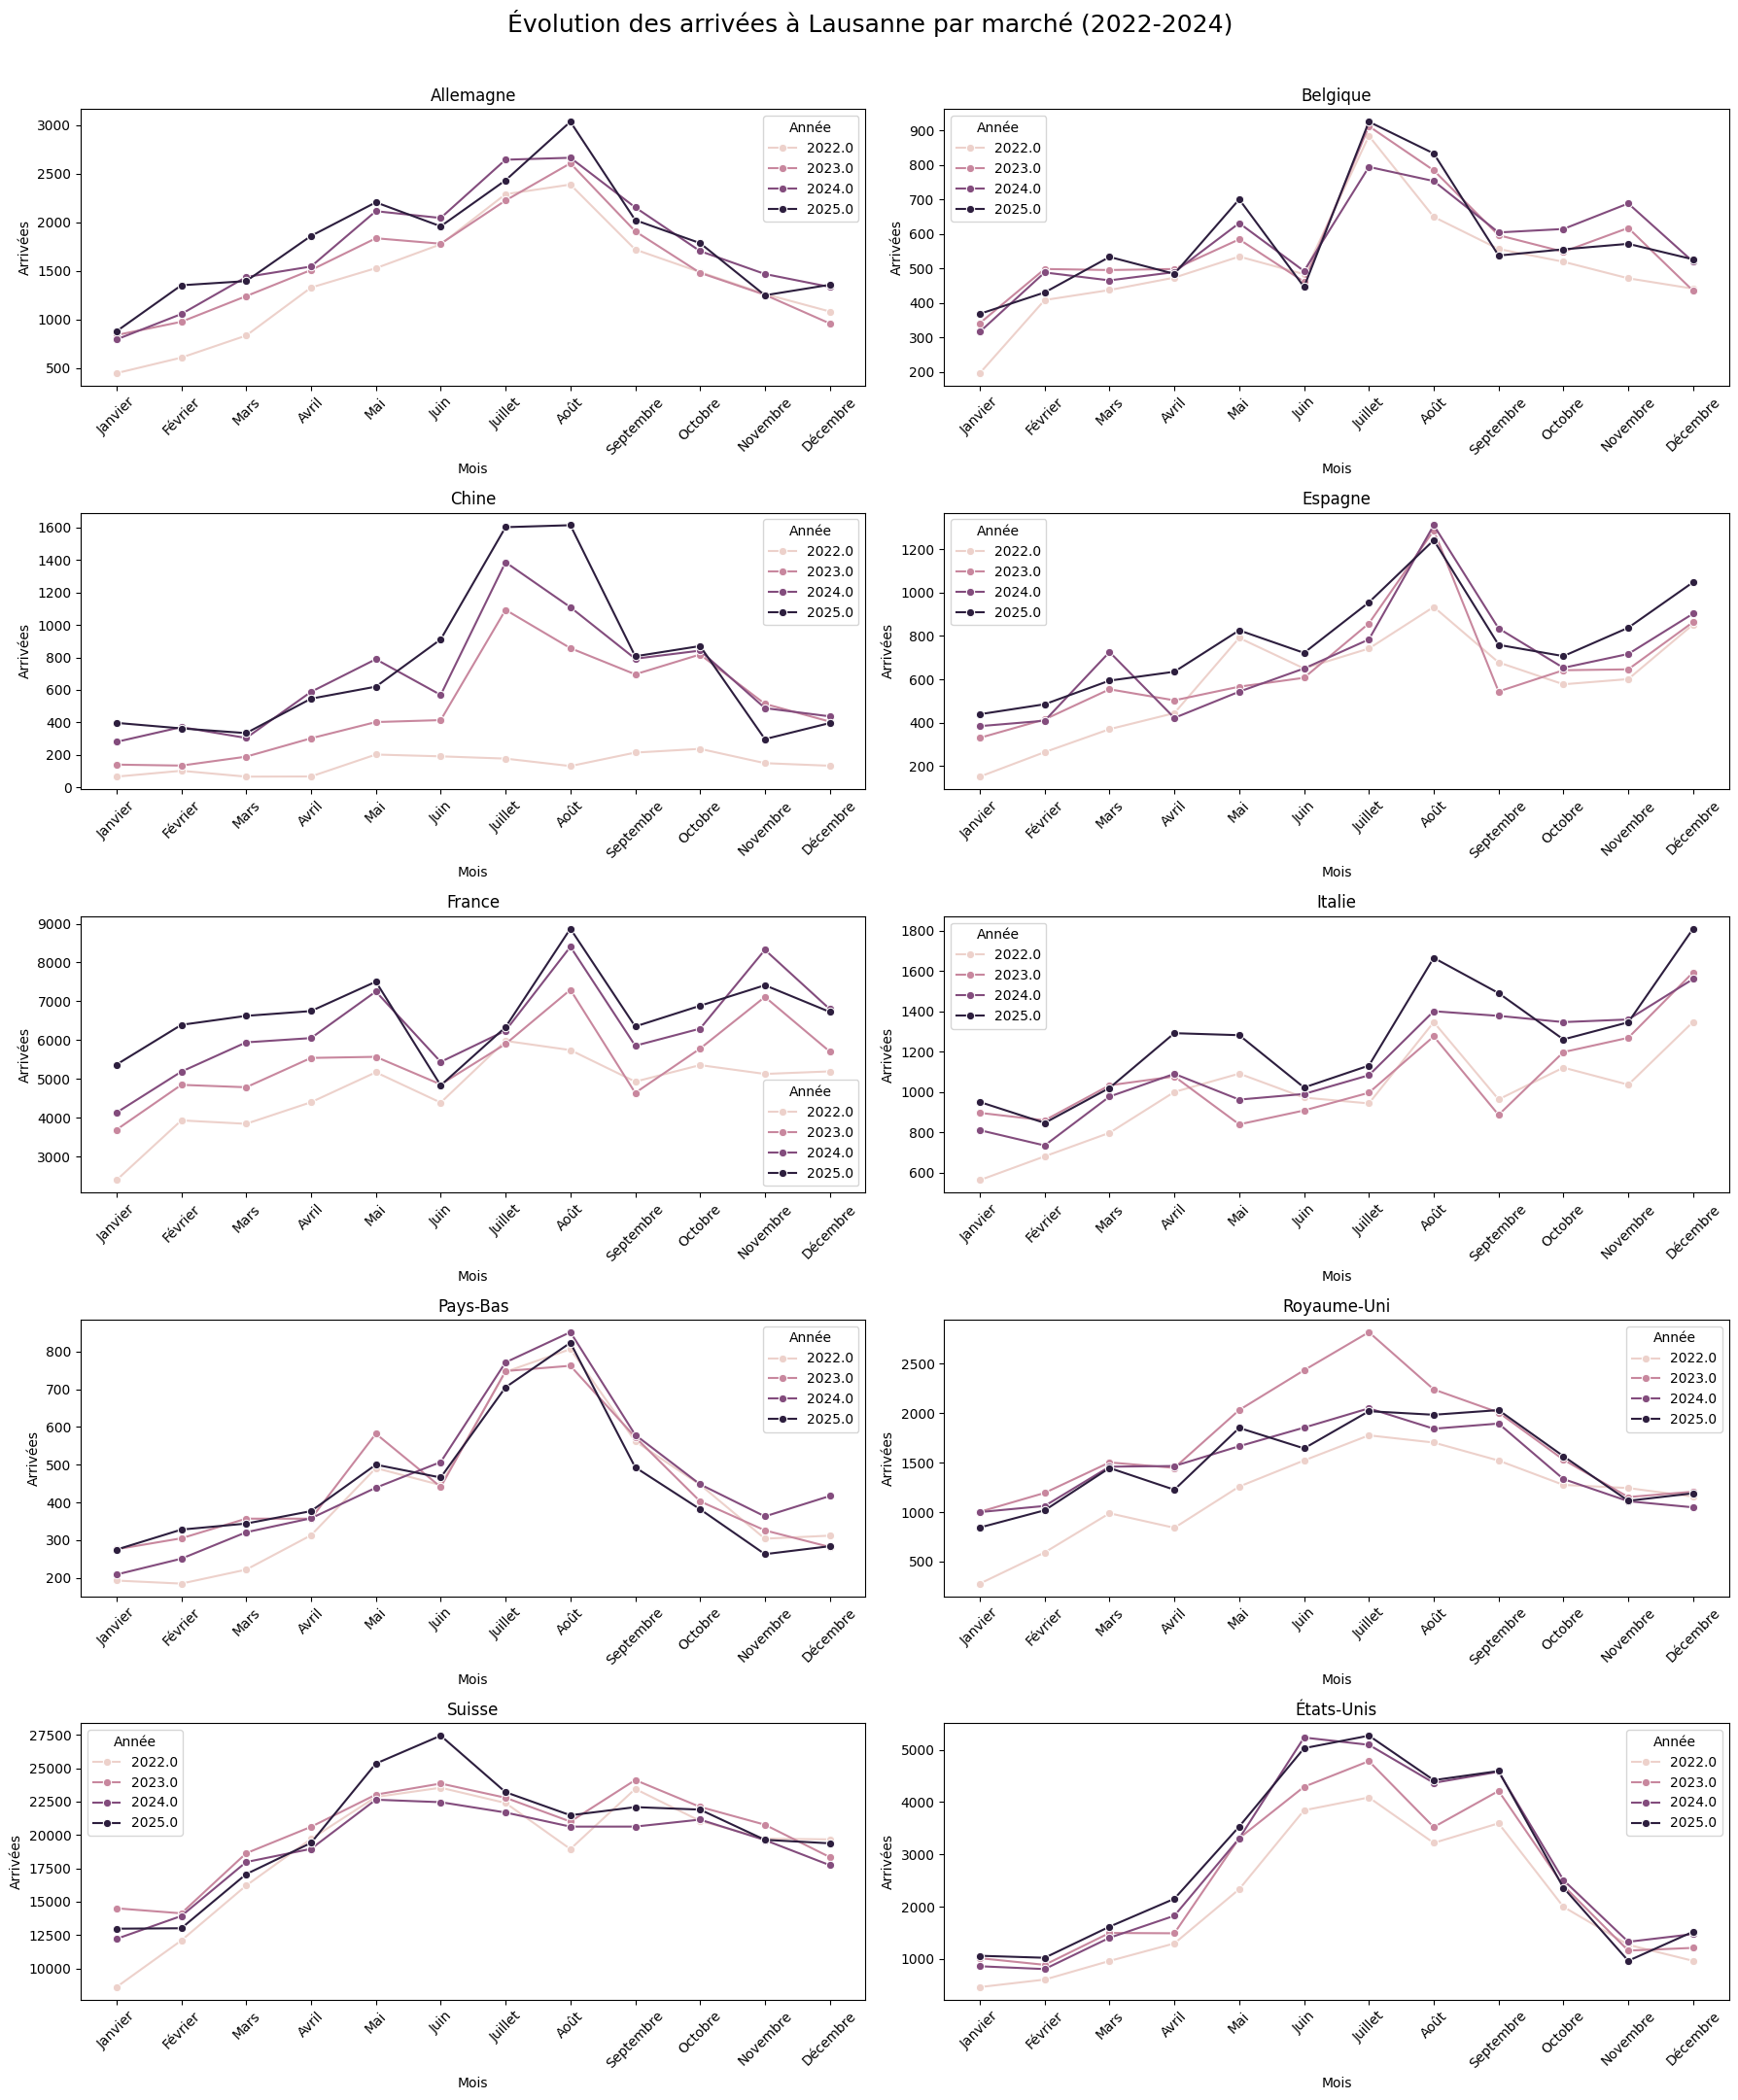

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# garder uniquement les années récentes
lausanne_recent = lausanne_top[lausanne_top["Année"].isin([2022, 2023, 2024, 2025])]

# ordre des mois
mois_ordre = [
    "Janvier","Février","Mars","Avril","Mai","Juin",
    "Juillet","Août","Septembre","Octobre","Novembre","Décembre"
]

lausanne_recent["Mois"] = pd.Categorical(
    lausanne_recent["Mois"],
    categories=mois_ordre,
    ordered=True
)

# liste des marchés
markets = lausanne_recent["Pays"].unique()

# création des 10 graphes
fig, axes = plt.subplots(5, 2, figsize=(18,22))  # ⬅️ plus grand
axes = axes.flatten()

for i, market in enumerate(markets):

    data_market = lausanne_recent[lausanne_recent["Pays"] == market]

    sns.lineplot(
        data=data_market,
        x="Mois",
        y="Arrivées",
        hue="Année",
        marker="o",
        ax=axes[i]
    )

    axes[i].set_title(market)
    axes[i].set_ylabel("Arrivées")
    axes[i].set_xlabel("Mois")

    # 🔧 rendre les mois lisibles
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle("Évolution des arrivées à Lausanne par marché (2022-2024)", fontsize=18)

# 🔧 évite que le titre chevauche
plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()

Je sais pas si vous aller réussir à run le code vu que j'ai importer depuis mon drive les base de données...

In [40]:
df_tidy["Nuitées"] = (
    df_tidy["Nuitées"]
    .astype(str)
    .str.replace(" ", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace("\xa0", "", regex=False)
)
df_tidy["Nuitées"] = pd.to_numeric(df_tidy["Nuitées"], errors="coerce")

In [41]:
import pandas as pd

# Reconstruire df_hesta depuis df_tidy
df_hesta = (
    df_tidy
    .groupby(["Commune", "Année", "Mois"], as_index=False)["Nuitées"]
    .sum()
)

# Reconstruire df_provenance depuis df_tidy
df_arr = df_tidy.pivot_table(
    index=["Année", "Mois", "Commune"],
    columns="Pays",
    values="Arrivées",
    aggfunc="sum"
).reset_index()
df_arr.columns = [col if col in ["Année", "Mois", "Commune"] else f"{col} Arrivées" for col in df_arr.columns]
df_arr.columns.name = None

df_nuit = df_tidy.pivot_table(
    index=["Année", "Mois", "Commune"],
    columns="Pays",
    values="Nuitées",
    aggfunc="sum"
).reset_index()
df_nuit.columns = [col if col in ["Année", "Mois", "Commune"] else f"{col} Nuitées" for col in df_nuit.columns]
df_nuit.columns.name = None

df_provenance = df_arr.merge(df_nuit, on=["Année", "Mois", "Commune"])

display(df_hesta.head())
display(df_provenance.head())

,Commune,Année,Mois,Nuitées
0,Basel,2013.0,Août,189806.0
1,Basel,2013.0,Avril,206002.0
2,Basel,2013.0,Décembre,155540.0
3,Basel,2013.0,Février,155426.0
4,Basel,2013.0,Janvier,134416.0


,Année,Mois,Commune,Afrique du Sud Arrivées,Allemagne Arrivées,Arabie saoudite Arrivées,Argentine Arrivées,Australie Arrivées,Autres Afrique Arrivées,Autres Afrique du Nord Arrivées,...,Suisse Nuitées,Suède Nuitées,Taïwan (Taipei chinois) Nuitées,Tchéquie Nuitées,Thaïlande Nuitées,Turquie Nuitées,Ukraine Nuitées,Égypte Nuitées,Émirats arabes unis Nuitées,États-Unis Nuitées
0,2013.0,Août,Basel,68.0,10025.0,129.0,35.0,497.0,112.0,35.0,...,23770.0,604.0,428.0,436.0,119.0,598.0,84.0,81.0,810.0,9473.0
1,2013.0,Août,Bern,21.0,4495.0,136.0,76.0,241.0,57.0,17.0,...,31098.0,632.0,668.0,263.0,257.0,230.0,124.0,17.0,651.0,4019.0
2,2013.0,Août,Davos,4.0,10630.0,37.0,8.0,47.0,9.0,0.0,...,35153.0,112.0,24.0,672.0,10.0,18.0,2.0,0.0,39.0,988.0
3,2013.0,Août,Genève,187.0,2858.0,6795.0,201.0,1113.0,534.0,526.0,...,26366.0,925.0,319.0,456.0,327.0,986.0,829.0,1435.0,10912.0,12593.0
4,2013.0,Août,Lausanne,48.0,1662.0,464.0,32.0,194.0,142.0,67.0,...,28611.0,388.0,186.0,146.0,131.0,512.0,223.0,143.0,1140.0,3675.0


In [42]:
# df_hesta a déjà les bonnes colonnes, pas besoin de renommer
# Garder seulement Lausanne
df_hesta_laus = df_hesta[df_hesta['Commune'] == 'Lausanne'].copy()

display(df_hesta_laus.head(10))

,Commune,Année,Mois,Nuitées
572,Lausanne,2013.0,Août,149892.0
573,Lausanne,2013.0,Avril,113920.0
574,Lausanne,2013.0,Décembre,96700.0
575,Lausanne,2013.0,Février,97214.0
576,Lausanne,2013.0,Janvier,90266.0
577,Lausanne,2013.0,Juillet,151704.0
578,Lausanne,2013.0,Juin,150942.0
579,Lausanne,2013.0,Mai,134816.0
580,Lausanne,2013.0,Mars,121650.0
581,Lausanne,2013.0,Novembre,118250.0


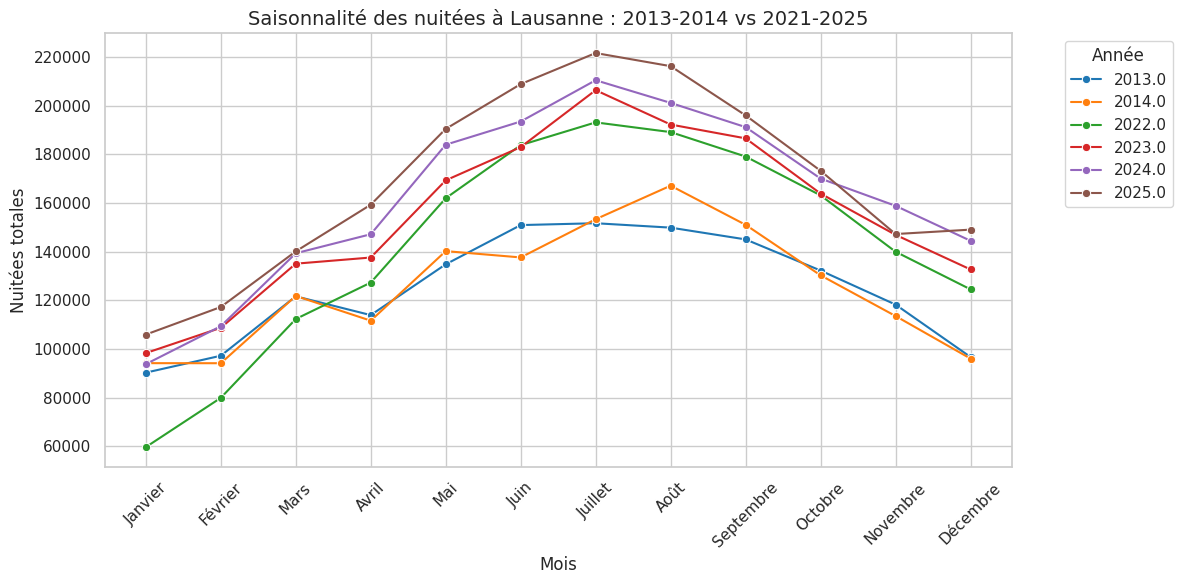

In [43]:
# Paramètres d'affichage
sns.set_theme(style="whitegrid")

#copie pour ne pas modifier le graphe initial
df_graph1 = df_hesta_laus.copy()

# Enlever la ligne des totaux annuel
df_graph1 = df_graph1[df_graph1["Mois"] != "Total de l'année"]

# "Année" et "Nuitées" sont-elles bien reconnues comme des nombres ?
df_graph1["Année"] = pd.to_numeric(df_graph1["Année"])
df_graph1["Nuitées"] = pd.to_numeric(df_graph1["Nuitées"])

# Déterminer les années qu'on veut garder
annees_cible = [2013, 2014, 2021, 2022, 2023, 2024, 2025]
df_graph1 = df_graph1[df_graph1["Année"].isin(annees_cible)]

# Ordonner chronologiquement les mois
ordre_mois = ["Janvier", "Février", "Mars", "Avril", "Mai", "Juin", "Juillet", "Août", "Septembre", "Octobre", "Novembre", "Décembre"]
df_graph1["Mois"] = pd.Categorical(df_graph1["Mois"], categories=ordre_mois, ordered=True)

#  Création de la figure
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_graph1, x="Mois", y="Nuitées", hue="Année", palette="tab10", marker="o")
plt.title("Saisonnalité des nuitées à Lausanne : 2013-2014 vs 2021-2025", fontsize=14)
plt.xlabel("Mois", fontsize=12)
plt.ylabel("Nuitées totales", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Année", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

In [44]:
# df_provenance a déjà les bonnes colonnes, pas besoin de renommer
# Suppression des lignes "Total de l'année"
df_provenance = df_provenance[df_provenance["Mois"] != "Total de l'année"]

df_provenance_laus = df_provenance[df_provenance["Commune"] == "Lausanne"].copy()
df_provenance_laus.head()

,Année,Mois,Commune,Afrique du Sud Arrivées,Allemagne Arrivées,Arabie saoudite Arrivées,Argentine Arrivées,Australie Arrivées,Autres Afrique Arrivées,Autres Afrique du Nord Arrivées,...,Suisse Nuitées,Suède Nuitées,Taïwan (Taipei chinois) Nuitées,Tchéquie Nuitées,Thaïlande Nuitées,Turquie Nuitées,Ukraine Nuitées,Égypte Nuitées,Émirats arabes unis Nuitées,États-Unis Nuitées
4,2013.0,Août,Lausanne,48.0,1662.0,464.0,32.0,194.0,142.0,67.0,...,28611.0,388.0,186.0,146.0,131.0,512.0,223.0,143.0,1140.0,3675.0
17,2013.0,Avril,Lausanne,19.0,1302.0,41.0,37.0,136.0,104.0,105.0,...,21832.0,564.0,87.0,110.0,248.0,306.0,250.0,99.0,246.0,3037.0
30,2013.0,Décembre,Lausanne,52.0,806.0,23.0,22.0,122.0,68.0,53.0,...,21393.0,228.0,21.0,111.0,81.0,278.0,130.0,125.0,216.0,1657.0
43,2013.0,Février,Lausanne,22.0,1063.0,24.0,40.0,119.0,94.0,60.0,...,18261.0,475.0,58.0,138.0,86.0,428.0,277.0,86.0,199.0,1988.0
56,2013.0,Janvier,Lausanne,31.0,891.0,37.0,53.0,178.0,142.0,44.0,...,16799.0,338.0,60.0,131.0,39.0,255.0,215.0,81.0,186.0,2164.0


/tmp/ipykernel_2397/4284237818.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_groupe_arr = df_recent_arr.groupby(["Mois", "Marché_Regroupé"])["Arrivées"].mean().unstack()


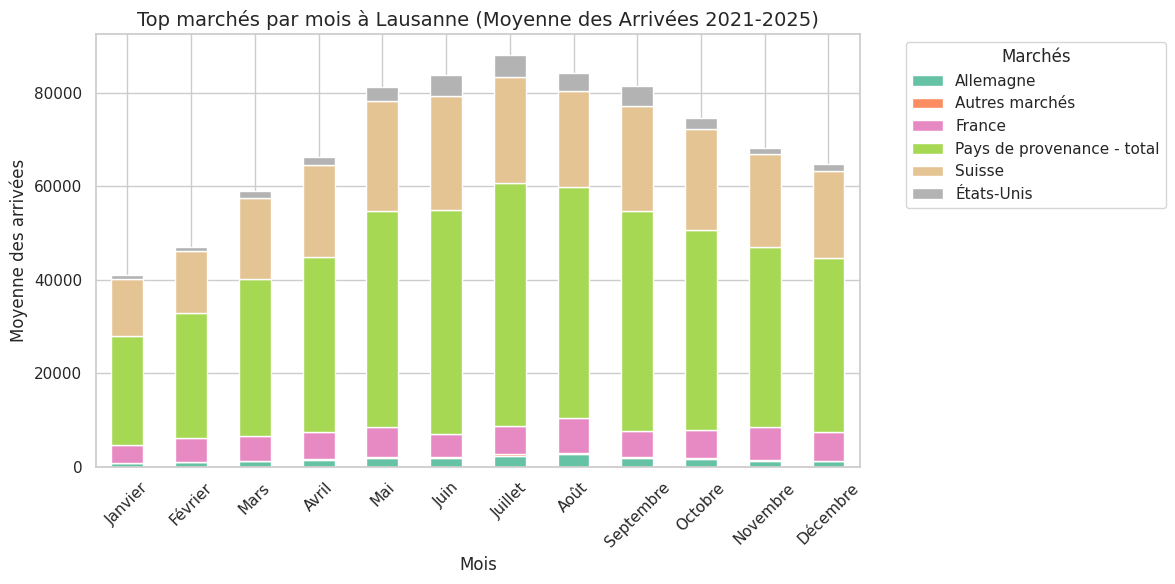

In [45]:
# Isoler colonnes arrivées
colonnes_arrivees = [col for col in df_provenance_laus.columns if str(col).endswith("Arrivées") and col != "Total Arrivées"]
df_arr = df_provenance_laus[["Année", "Mois"] + colonnes_arrivees].copy()

# convertir en nbres
for col in colonnes_arrivees:
    df_arr[col] = pd.to_numeric(df_arr[col], errors="coerce").fillna(0)

# Melt tableau
df_long_arr = pd.melt(df_arr, id_vars=["Année", "Mois"], var_name="Marché", value_name="Arrivées")
df_long_arr["Marché"] = df_long_arr["Marché"].str.replace(" Arrivées", "")

# Définir les années qu'on veut analyser
df_long_arr["Année"] = pd.to_numeric(df_long_arr["Année"])
df_recent_arr = df_long_arr[df_long_arr["Année"].isin([2021, 2022, 2023, 2024, 2025])].copy()

top_5_marches = df_recent_arr.groupby("Marché")["Arrivées"].sum().nlargest(5).index.tolist()
df_recent_arr["Marché_Regroupé"] = df_recent_arr["Marché"].apply(lambda x: x if x in top_5_marches else "Autres marchés")
ordre_mois = ["Janvier", "Février", "Mars", "Avril", "Mai", "Juin", "Juillet", "Août", "Septembre", "Octobre", "Novembre", "Décembre"]
df_recent_arr["Mois"] = pd.Categorical(df_recent_arr["Mois"], categories=ordre_mois, ordered=True)

# Créer graphique
df_groupe_arr = df_recent_arr.groupby(["Mois", "Marché_Regroupé"])["Arrivées"].mean().unstack()
df_groupe_arr.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="Set2")

plt.title("Top marchés par mois à Lausanne (Moyenne des Arrivées 2021-2025)", fontsize=14)
plt.xlabel("Mois", fontsize=12)
plt.ylabel("Moyenne des arrivées", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Marchés", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [46]:
donnees_tableau = []
df_provenance_laus["Année"] = pd.to_numeric(df_provenance_laus["Année"], errors="coerce")
# On filtre le dataframe d'origine pour la même période (2021-2025)
df_prov_recent = df_provenance_laus[df_provenance_laus["Année"].isin([2021, 2022, 2023, 2024, 2025])].copy()

for marche in top_5_marches:
    col_arr = f"{marche} Arrivées"
    col_nuit = f"{marche} Nuitées"

    # calcule de la moyenne mensuelle des arrivées et des nuitées
    moyenne_arr = pd.to_numeric(df_prov_recent[col_arr], errors="coerce").mean()
    moyenne_nuit = pd.to_numeric(df_prov_recent[col_nuit], errors="coerce").mean()

    # Calcule DMS (durée moyenne de séjour)
    dms = moyenne_nuit / moyenne_arr if moyenne_arr > 0 else 0

    donnees_tableau.append({
        "Marché (Top 5)": marche,
        "Arrivées Moyennes / mois": round(moyenne_arr, 0),
        "Nuitées Moyennes / mois": round(moyenne_nuit, 0),
        "Durée Moyenne de Séjour (Jours)": round(dms, 2)
    })


df_recapitulatif = pd.DataFrame(donnees_tableau)
display(df_recapitulatif)

,Marché (Top 5),Arrivées Moyennes / mois,Nuitées Moyennes / mois,Durée Moyenne de Séjour (Jours)
0,Pays de provenance - total,40194.0,78586.0,1.96
1,Suisse,19682.0,35428.0,1.80
2,France,5796.0,9802.0,1.69
3,États-Unis,2517.0,5782.0,2.30
4,Allemagne,1622.0,3217.0,1.98


In [47]:
import pandas as pd

# définir les saisons
dico_saisons = {
    "Janvier": "3. Basse", "Février": "3. Basse", "Mars": "3. Basse", "Novembre": "3. Basse", "Décembre": "3. Basse",
    "Avril": "2. Moyenne", "Mai": "2. Moyenne", "Octobre": "2. Moyenne",
    "Juin": "1. Haute", "Juillet": "1. Haute", "Août": "1. Haute", "Septembre": "1. Haute"
}

df_saisons = df_provenance_laus.copy()
df_saisons["Saison"] = df_saisons["Mois"].map(dico_saisons)
df_saisons["Année"] = pd.to_numeric(df_saisons["Année"], errors="coerce")
df_recent_saisons = df_saisons[df_saisons["Année"].isin([2021, 2022, 2023, 2024, 2025])].copy()

tous_les_marches = [col.replace(" Arrivées", "") for col in df_provenance_laus.columns if str(col).endswith(" Arrivées") and col != "Total Arrivées"]


resultats_finaux = []
for saison in ["1. Haute", "2. Moyenne", "3. Basse"]:
    df_filtre = df_recent_saisons[df_recent_saisons["Saison"] == saison]

    donnees_saison_actuelle = []
    for marche in tous_les_marches:
        col_arr = f"{marche} Arrivées"
        col_nuit = f"{marche} Nuitées"
        # Moyennes mensuelles pendant cette saison
        moyenne_arr = pd.to_numeric(df_filtre[col_arr], errors="coerce").mean()
        moyenne_nuit = pd.to_numeric(df_filtre[col_nuit], errors="coerce").mean()
        # On ne garde que les marchés qui ont eu des visiteurs
        if moyenne_arr > 0:
            dms = moyenne_nuit / moyenne_arr
            donnees_saison_actuelle.append({
                "Saison": saison.replace("1. ", "").replace("2. ", "").replace("3. ", ""), # On nettoie le nom
                "Marché": marche,
                "Arrivées Moy. / mois": round(moyenne_arr, 0),
                "Nuitées Moy. / mois": round(moyenne_nuit, 0),
                "Durée de Séjour (DMS)": round(dms, 2)
            })

    df_stats_saison = pd.DataFrame(donnees_saison_actuelle)

    # Top 10
    top_10 = df_stats_saison.sort_values(by="Nuitées Moy. / mois", ascending=False).head(10)
    resultats_finaux.append(top_10)

df_tableau_saisons = pd.concat(resultats_finaux).reset_index(drop=True)
display(df_tableau_saisons.style.set_properties(**{"text-align": "center", "border": "1px solid black"}))

,Saison,Marché,Arrivées Moy. / mois,Nuitées Moy. / mois,Durée de Séjour (DMS)
0,Haute,Pays de provenance - total,49113.000000,98532.000000,2.010000
1,Haute,Suisse,22482.000000,41631.000000,1.850000
2,Haute,France,6005.000000,10467.000000,1.740000
3,Haute,États-Unis,4383.000000,9823.000000,2.240000
4,Haute,Allemagne,2228.000000,4340.000000,1.950000
5,Haute,Royaume-Uni,1960.000000,4147.000000,2.120000
6,Haute,Italie,1153.000000,2190.000000,1.900000
7,Haute,Espagne,847.000000,1856.000000,2.190000
8,Haute,Arabie saoudite,424.000000,1534.000000,3.610000
9,Haute,Belgique,669.000000,1391.000000,2.080000


/tmp/ipykernel_2397/2319489167.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10_trie_dms, x="DMS", y="Marché", palette="mako")


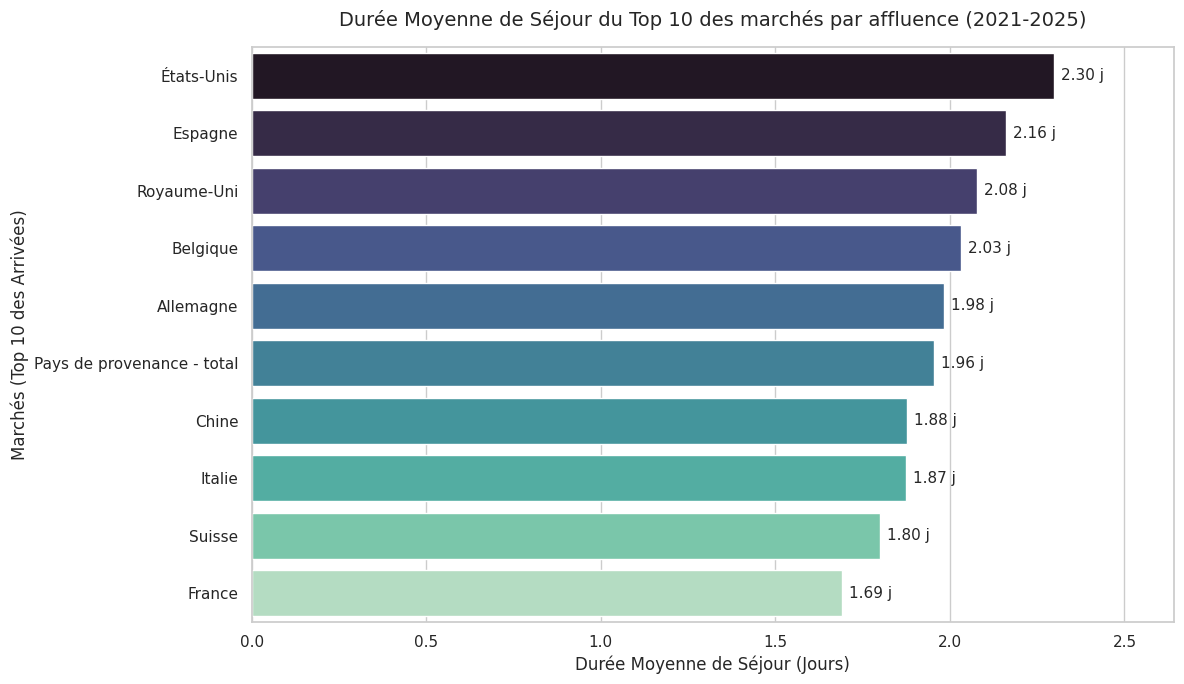

In [48]:
df_prov_recent = df_provenance_laus.copy()
df_prov_recent["Année"] = pd.to_numeric(df_prov_recent["Année"], errors="coerce")
df_prov_recent = df_prov_recent[df_prov_recent["Année"].isin([2021, 2022, 2023, 2024, 2025])]

#Identifier tous les marchés disponibles
tous_les_marches = [col.replace(" Arrivées", "") for col in df_provenance_laus.columns if str(col).endswith(" Arrivées") and col != "Total Arrivées"]

donnees_marches = []

# Calculer les moyennes par marché
for marche in tous_les_marches:
    col_arr = f"{marche} Arrivées"
    col_nuit = f"{marche} Nuitées"

    moyenne_arr = pd.to_numeric(df_prov_recent[col_arr], errors="coerce").mean()
    moyenne_nuit = pd.to_numeric(df_prov_recent[col_nuit], errors="coerce").mean()

    if moyenne_arr > 0:
        dms = moyenne_nuit / moyenne_arr
        donnees_marches.append({
            "Marché": marche,
            "Arrivées Moyennes": moyenne_arr,
            "DMS": dms
        })

df_stats = pd.DataFrame(donnees_marches)

#  Top 10 selon arrivées
top_10_arrivees = df_stats.sort_values(by="Arrivées Moyennes", ascending=False).head(10).copy()

# DMS
top_10_trie_dms = top_10_arrivees.sort_values(by="DMS", ascending=False)

# Création du graphique
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=top_10_trie_dms, x="DMS", y="Marché", palette="mako")
plt.title("Durée Moyenne de Séjour du Top 10 des marchés par affluence (2021-2025)", fontsize=14, pad=15)
plt.xlabel("Durée Moyenne de Séjour (Jours)", fontsize=12)
plt.ylabel("Marchés (Top 10 des Arrivées)", fontsize=12)

for p in ax.patches:
    ax.annotate(f"{p.get_width():.2f} j",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha="left", va="center",
                xytext=(5, 0),
                textcoords="offset points",
                fontsize=11)
plt.xlim(0, top_10_trie_dms["DMS"].max() * 1.15)
plt.tight_layout()
plt.show()

arrivée totales tout pays confondu (est ce que c'est tout pays confondus ou top marché??)

In [61]:
# Colonnes arrivées et nuitées
cols_arrivees = [col for col in df_provenance_laus.columns if 'Arrivées' in col]
cols_nuitees = [col for col in df_provenance_laus.columns if 'Nuitées' in col]

# Total tous pays par ligne
total_arrivees = df_provenance_laus[cols_arrivees].sum(axis=1)
total_nuitees = df_provenance_laus[cols_nuitees].sum(axis=1)

# Durée moyenne de séjour tous pays confondus
duree_moyenne = total_nuitees.sum() / total_arrivees.sum()

print(f"Durée moyenne de séjour (tous pays confondus) : {duree_moyenne:.2f} jours")

Durée moyenne de séjour (tous pays confondus) : 2.00 jours


In [62]:
# Vérifier sans arrondi
duree_moyenne = total_nuitees.sum() / total_arrivees.sum()
print(f"Valeur exacte : {duree_moyenne}")  # Affiche tous les décimales

# Vérifier les totaux bruts
print(f"Total nuitées : {total_nuitees.sum():,.0f}")
print(f"Total arrivées : {total_arrivees.sum():,.0f}")

Valeur exacte : 1.9996507924711595
Total nuitées : 19,480,714
Total arrivées : 9,742,058


comparer lausanne avec les autres villes suisse

In [49]:
df_tidy[df_tidy["Pays"] == "Pays de provenance - total"]

,Année,Mois,Commune,Commune_nom,Pays,Arrivées,Nuitées,Request
51,2013.0,Août,Basel,Basel,Pays de provenance - total,51329.0,94903.0,NaN
125,2013.0,Août,Bern,Bern,Pays de provenance - total,45192.0,78139.0,NaN
199,2013.0,Août,Davos,Davos,Pays de provenance - total,29986.0,92045.0,NaN
273,2013.0,Août,Genève,Genève,Pays de provenance - total,89560.0,192240.0,NaN
347,2013.0,Août,Lausanne,Lausanne,Pays de provenance - total,36706.0,74946.0,NaN
...,...,...,...,...,...,...,...,...
137247,2025.0,Total de l'année,Nendaz,Nendaz,Pays de provenance - total,22790.0,40655.0,NaN
137321,2025.0,Total de l'année,Saas-Fee,Zermatt,Pays de provenance - total,97248.0,271313.0,NaN
137395,2025.0,Total de l'année,Samedan,St Moritz,Pays de provenance - total,25210.0,52632.0,NaN
137469,2025.0,Total de l'année,St. Gallen,St Gallen,Pays de provenance - total,164156.0,310568.0,NaN


In [50]:
print(df_tidy["Commune_nom"].unique())

['Basel' 'Bern' 'Davos' 'Genève' 'Lausanne' 'Locarno' 'Luzern' 'Montreux'
 'Nendaz' 'Zermatt' 'St Moritz' 'St Gallen' 'Zürich']


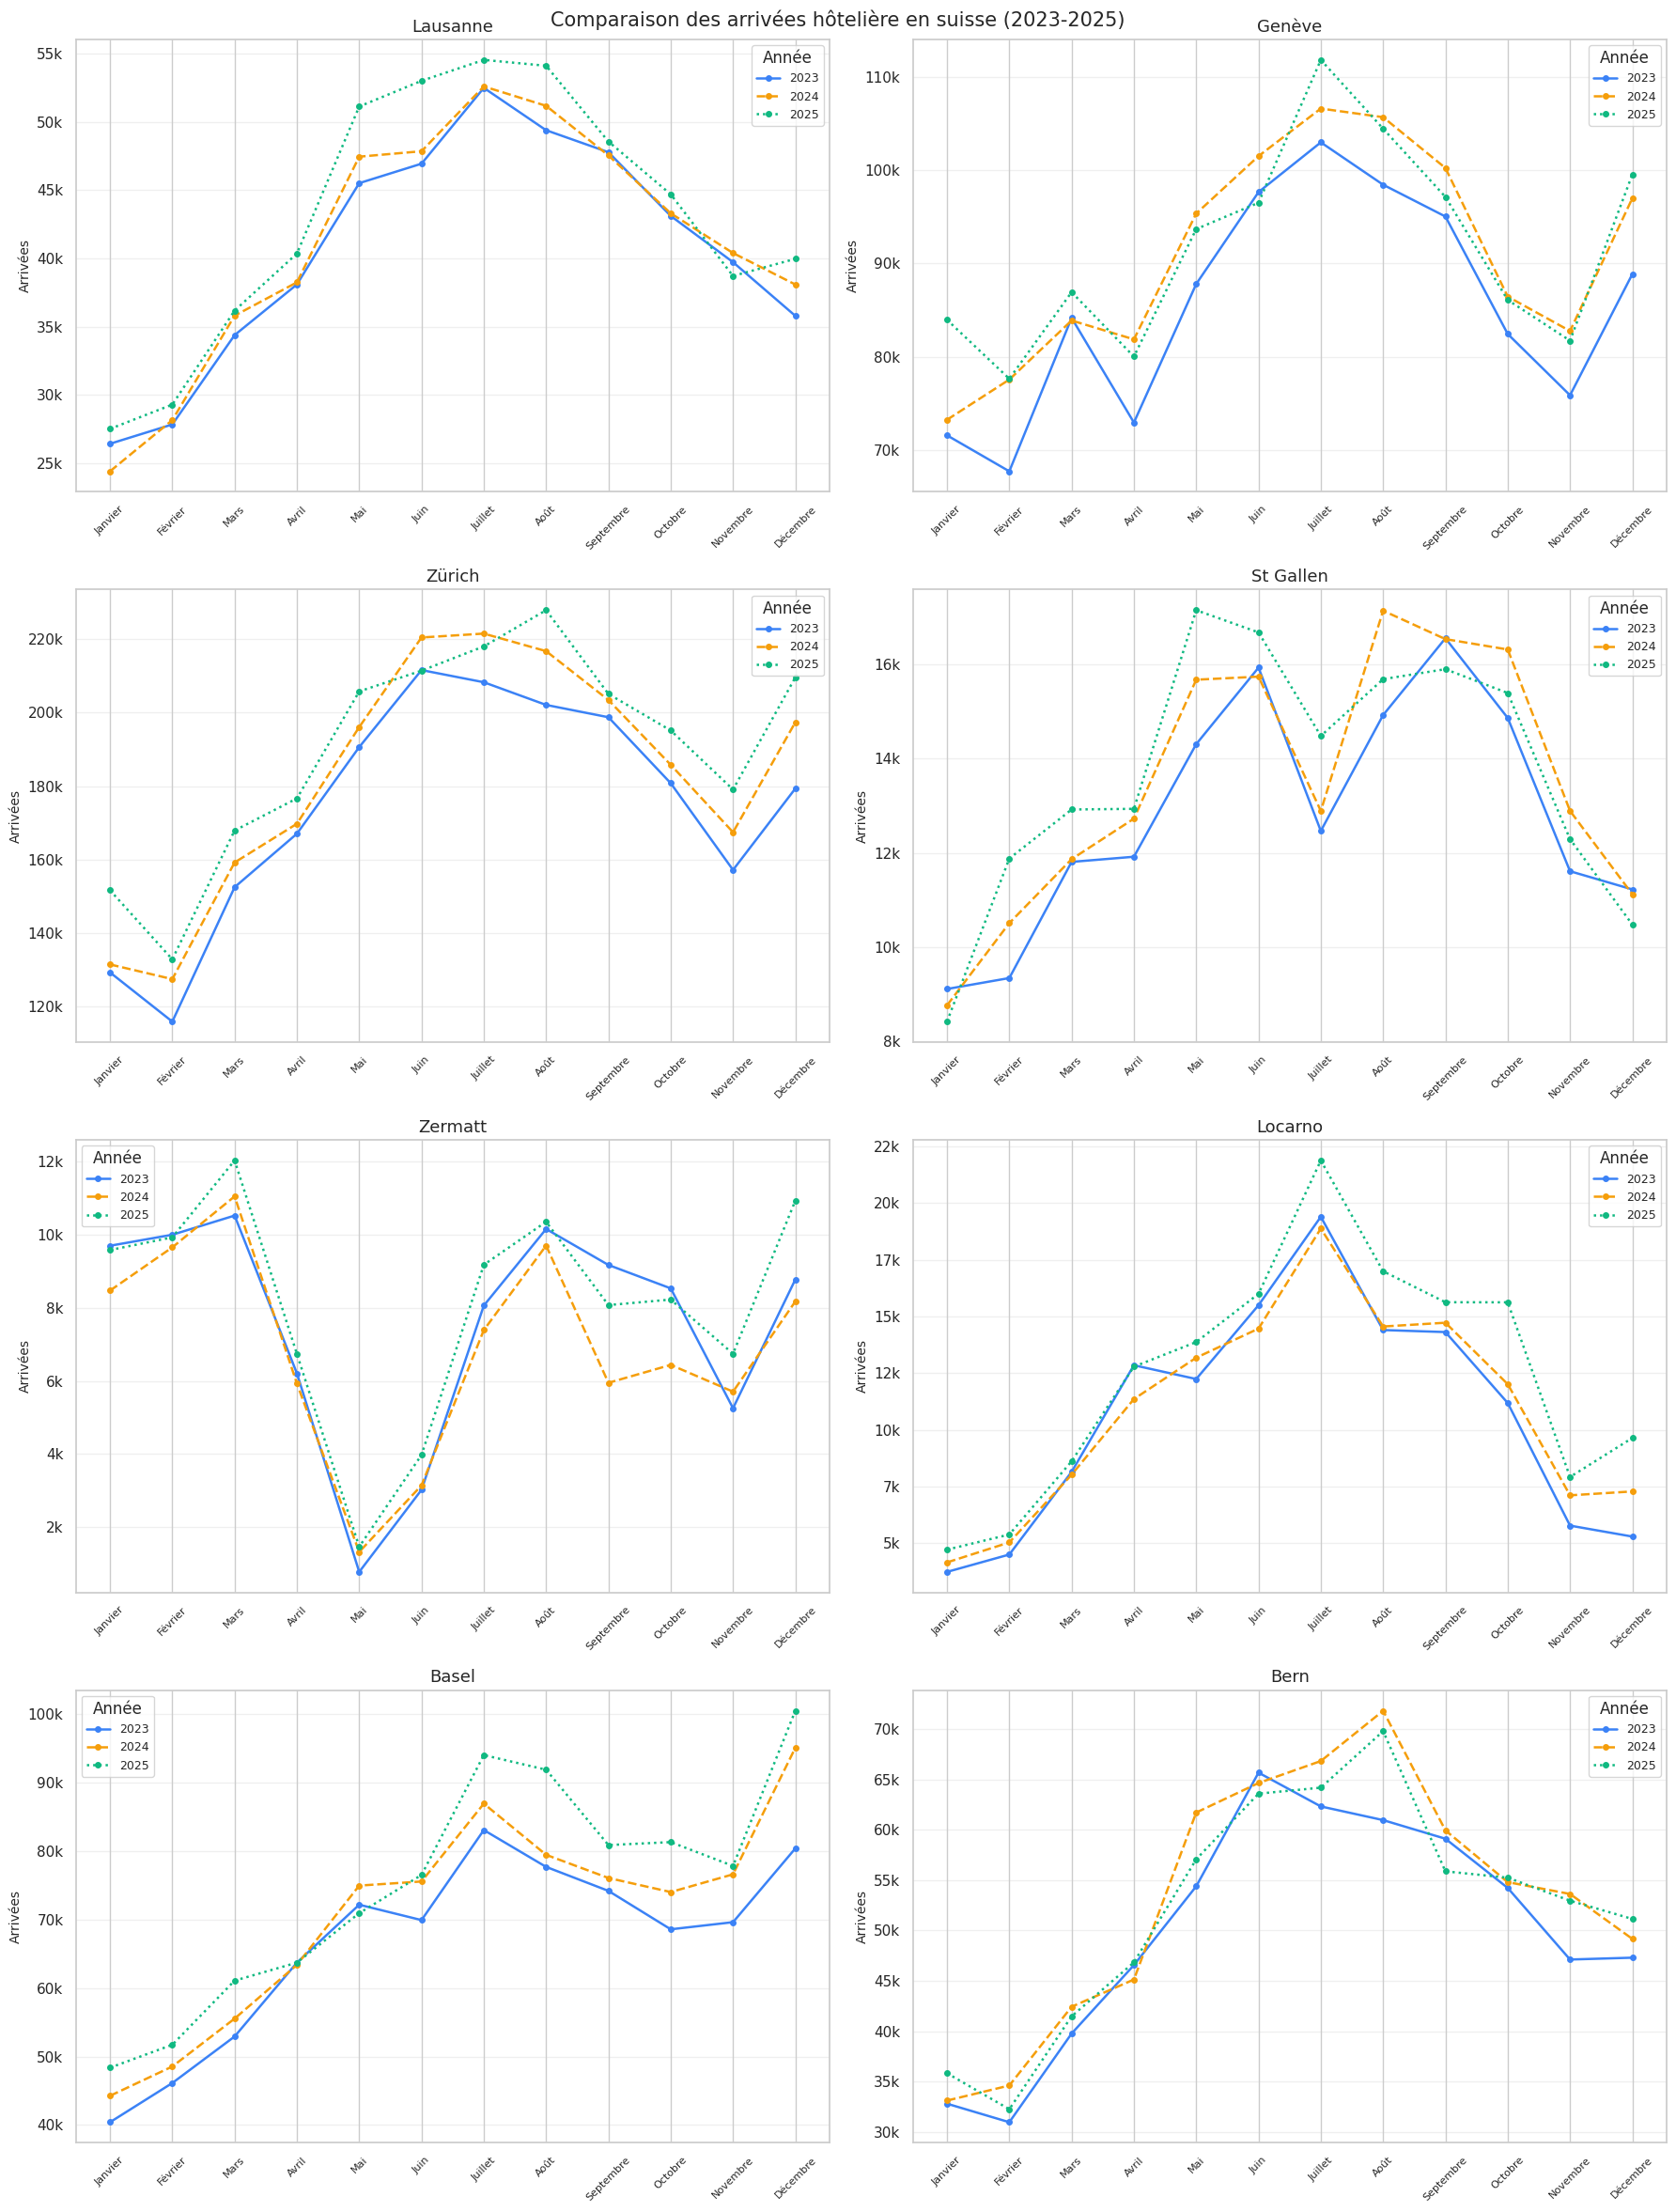

In [51]:
import matplotlib.ticker as mticker
villes_cibles = ["Lausanne", "Genève", "Zürich", "St Gallen", "Zermatt", "Locarno", "Basel", "Bern"]
annees_cibles = [2023, 2024, 2025]
ordre_mois = ["Janvier","Février","Mars","Avril","Mai","Juin",
              "Juillet","Août","Septembre","Octobre","Novembre","Décembre"]

# Option A : on garde uniquement le total toutes nationalités
df_comp = df_tidy[
    (df_tidy["Pays"] == "Pays de provenance - total") &
    (df_tidy["Commune_nom"].isin(villes_cibles)) &
    (df_tidy["Année"].isin(annees_cibles)) &
    (df_tidy["Mois"] != "Total de l'année")
].copy()

df_comp["Mois"] = pd.Categorical(df_comp["Mois"], categories=ordre_mois, ordered=True)
df_comp["Année"] = pd.to_numeric(df_comp["Année"])
df_comp["Arrivées"] = pd.to_numeric(df_comp["Arrivées"], errors="coerce")

couleurs = {2023: "#3b82f6", 2024: "#f59e0b", 2025: "#10b981"}
styles   = {2023: "-",       2024: "--",       2025: ":"}

fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()

for i, ville in enumerate(villes_cibles):
    ax = axes[i]
    df_ville = df_comp[df_comp["Commune_nom"] == ville]

    for annee in annees_cibles:
        df_an = df_ville[df_ville["Année"] == annee].sort_values("Mois")
        if df_an.empty:
            print(f"⚠️ Aucune donnée : {ville} / {annee}")
            continue
        ax.plot(df_an["Mois"], df_an["Arrivées"],
                label=str(annee),
                color=couleurs[annee],
                linestyle=styles[annee],
                marker="o", markersize=4, linewidth=1.8)

    ax.set_title(ville, fontsize=13)
    ax.set_ylabel("Arrivées", fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k" if x >= 1000 else str(int(x)))
    )
    ax.legend(title="Année", fontsize=9)
    ax.grid(axis="y", alpha=0.3)



plt.suptitle("Comparaison des arrivées hôtelière en suisse (2023-2025)", fontsize=15)
plt.tight_layout()
plt.show()

Useless sert a remplir pour GAMMA

In [52]:
df_tableau = df_tidy[
    (df_tidy["Pays"] == "Pays de provenance - total") &
    (df_tidy["Commune_nom"].isin(["Lausanne", "Bern", "Basel", "Zürich", "St Gallen",])) &
    (df_tidy["Année"].isin([2023, 2024, 2025])) &
    (df_tidy["Mois"] != "Total de l'année")
].copy()

df_tableau["Arrivées"] = pd.to_numeric(df_tableau["Arrivées"], errors="coerce")
df_tableau["Année"] = pd.to_numeric(df_tableau["Année"])

ordre_mois = ["Janvier","Février","Mars","Avril","Mai","Juin",
              "Juillet","Août","Septembre","Octobre","Novembre","Décembre"]
df_tableau["Mois"] = pd.Categorical(df_tableau["Mois"], categories=ordre_mois, ordered=True)

df_pivot = df_tableau.pivot_table(
    index=["Commune_nom", "Mois"],
    columns="Année",
    values="Arrivées",
    aggfunc="sum"
).reset_index()

df_pivot.columns.name = None
df_pivot.columns = ["Ville", "Mois", "2023", "2024", "2025"]

display(df_pivot.sort_values(["Ville", "Mois"]))

/tmp/ipykernel_2397/3648136250.py:15: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_pivot = df_tableau.pivot_table(


,Ville,Mois,2023,2024,2025
0,Basel,Janvier,40413.0,44265.0,48367.0
1,Basel,Février,46132.0,48540.0,51714.0
2,Basel,Mars,52920.0,55533.0,61075.0
3,Basel,Avril,63699.0,63379.0,63701.0
4,Basel,Mai,72154.0,74945.0,70922.0
5,Basel,Juin,69910.0,75544.0,76495.0
6,Basel,Juillet,83049.0,86907.0,93994.0
7,Basel,Août,77674.0,79436.0,91855.0
8,Basel,Septembre,74173.0,76055.0,80860.0
9,Basel,Octobre,68566.0,74004.0,81290.0
